# 21 · HID multilevel v1: reversible words at several widths and levels

**Question.** If a bit string is cut into words of width b (8 widths, 2 origins each)
and consecutive words are paired again and again (levels 1–4), do exact grammar
proposals over those word streams ever give a *shorter complete archive* than the
accepted search-v2 method (k = 1, "A0")? And where, by width and level, does
repetition support break down?

**Design.** 96 previously exposed strings, four arms: A0 (k = 1), A1 (width 8, level 1),
A2 (8 widths, level 1), A3 (8 widths, levels 1–4). Every augmentation starts from the
saved, verified A0 archive and may replace it only with a strictly shorter, independently
decoded archive. Every word, every dictionary entry, prefix and suffix is paid for in
the archive. Proposals per view: G0 runs, G1 the owner pair grammar, G2/G3 occurrence-gap
templates with paid patches.

This is exploratory, descriptive work on exposed data: no interval, no test, no
generalization, no fractal or causal claim. Run the first cell first.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
from pathlib import Path
_cands = [Path.cwd(), Path.cwd() / "index-deconvolution", Path(ROOT)]
ID_ROOT = next(p.resolve() for p in _cands
               if (p / "PROTOCOL_order_discovery.md").is_file()
               and (p / "results" / "hierarchy_multilevel_v1" / "multilevel-feasibility-v1-r1").is_dir())
ROOT = str(ID_ROOT)
for _p in (os.path.join(os.path.dirname(ROOT), "src"), ROOT):
    while _p in sys.path:
        sys.path.remove(_p)
    sys.path.insert(0, _p)
sys.modules.pop("hierarchy", None)          # a sibling repo ships a module "hierarchy"
import json, hashlib, csv, collections, statistics
import numpy as np
import matplotlib.pyplot as plt
from hierarchy.decode import decode_archive                 # saved archives only
from hierarchy.ledger import archive_ledger                 # field ledger of saved bytes

RUN = ID_ROOT / "results" / "hierarchy_multilevel_v1" / "multilevel-feasibility-v1-r1"
def load(p):
    return json.loads(Path(p).read_text())
summary, decision = load(RUN / "summary.json"), load(RUN / "DECISION.json")
verification, audit = load(RUN / "verification.json"), load(RUN / "arithmetic_audit.json")
lock_sha = (RUN / "implementation_lock.sha256").read_text().strip()
def table(name):
    with open(RUN / "tables" / name) as fh:
        return list(csv.DictReader(fh))
strings, views, gmap = table("per_string.csv"), table("views_A3.csv"), table("gap_map_A3.csv")
def num(x):
    return None if x in ("", "None", None) else float(x)
print("lock:", lock_sha[:16], "| engineering verdict:", decision["engineering_verdict"],
      "| label:", decision["recommendation"])
print("verification pass:", verification["verification_pass"], "| audit pass:", audit["pass"],
      "| archives re-read by the audit:", audit["archives_read"])

lock: 4d1908ab4ec81334 | engineering verdict: VALID_COMPLETE | label: NO_RETAINED_GAIN
verification pass: True | audit pass: True | archives re-read by the audit: 1248


## 1. Completeness and the headline

Every count below is read from `summary.json`; the label rule is fixed in the protocol
(NO_RETAINED_GAIN if A3 never beats A0 on the 96 strings).

In [3]:
for k, v in summary["counts"].items():
    print(f"{k:34s} {v}")
rec = summary["recommendation"]
print()
print("label:", rec["label"], "| A3 < A0 on", rec["a3_beats_a0_strings"], "strings;",
      "A3 < A2 on", rec["a3_beats_a2_strings"], "; A2 < A0 on", rec["a2_beats_a0_strings"])

augmentation_jobs_intended         288
augmentation_jobs_with_rows        288
augmentation_rows_valid            288
baseline_jobs_intended             96
baseline_jobs_with_rows            96
baseline_reproduced                96
derived_composite_records          288
derived_portfolio_references       96
imported_reference_problems        0
imported_reference_records         864
new_encoder_jobs                   384
search_complete                    288
strings                            96
traces                             288
view_records_A3                    6144

label: NO_RETAINED_GAIN | A3 < A0 on 0 strings; A3 < A2 on 0 ; A2 < A0 on 0


## 2. Contrasts, with their reference points in the same table

saving(A, B) = (bits(B) − bits(A)) / n, positive when A is shorter; averaged base/ragged,
then replicates, then the 24 family-length cells equally. The A0 rows give the reference
distribution against which the composites must be read.

In [4]:
print(f"{'contrast':22s} {'equal-cell mean':>16s}  strings b/t/w     cells b/t/w")
for k, v in summary["contrasts"].items():
    s, c = v["strings"], v["cells_sign"]
    print(f"{k:22s} {v['aggregate']:16.6f}  {s['better']:3d}/{s['tie']:3d}/{s['worse']:3d}      "
          f"{c['better']:2d}/{c['tie']:2d}/{c['worse']:2d}")

contrast                equal-cell mean  strings b/t/w     cells b/t/w
A0_vs_pair_grammar             0.351713   87/  0/  9      22/ 0/ 2
A0_vs_portfolio               -0.045188   21/ 12/ 63       5/ 3/16
A1_vs_A0                       0.000000    0/ 96/  0       0/24/ 0
A1_vs_pair_grammar             0.351713   87/  0/  9      22/ 0/ 2
A1_vs_portfolio               -0.045188   21/ 12/ 63       5/ 3/16
A2_vs_A0                       0.000000    0/ 96/  0       0/24/ 0
A2_vs_A1                       0.000000    0/ 96/  0       0/24/ 0
A2_vs_pair_grammar             0.351713   87/  0/  9      22/ 0/ 2
A2_vs_portfolio               -0.045188   21/ 12/ 63       5/ 3/16
A3_vs_A0                       0.000000    0/ 96/  0       0/24/ 0
A3_vs_A2                       0.000000    0/ 96/  0       0/24/ 0
A3_vs_pair_grammar             0.351713   87/  0/  9      22/ 0/ 2
A3_vs_portfolio               -0.045188   21/ 12/ 63       5/ 3/16


## 3. Rendering the object: the closest any proposal came

Saved per-view records give each view's shortest admissible archive. For every string we
take the view that came closest to A0 and print the excess. One string family is
periodic with a period that is itself a word width; there the G0 proposal (a REPEAT of
one word) reproduces the A0 bytes exactly — a duplicate, not a gain. These are
illustrations, not a selection of typical behaviour.

In [5]:
best = {}
for r in views:
    if r["best_bits"]:
        b, a = int(r["best_bits"]), int(r["a0_bits"])
        if r["case_id"] not in best or b < best[r["case_id"]][0]:
            best[r["case_id"]] = (b, a, r["width"], r["level"], r["origin"])
rel = sorted((b - a) / a for b, a, *_ in best.values())
print("strings:", len(best), "| min relative excess over A0:", round(rel[0], 4),
      "| median:", round(statistics.median(rel), 4), "| max:", round(rel[-1], 4))
for cid, (b, a, w, l, o) in sorted(best.items(), key=lambda kv: (kv[1][0] - kv[1][1]) / kv[1][1])[:4]:
    print(f"  {cid:38s} best {b:5d} bits vs A0 {a:5d}  (width {w}, level {l}, origin {o})")

strings: 96 | min relative excess over A0: 0.0 | median: 0.5254 | max: 24.2727
  confirmation-F05-1024-3000-base        best   144 bits vs A0   144  (width 32, level 1, origin 0)
  confirmation-F05-1024-3000-ragged      best   200 bits vs A0   200  (width 32, level 1, origin 0)
  confirmation-F09-4096-3000-base        best  4024 bits vs A0  3920  (width 8, level 1, origin 4)
  confirmation-F09-4096-3000-ragged      best  4048 bits vs A0  3920  (width 8, level 1, origin 4)


In [6]:
cid = min(best, key=lambda c: ((best[c][0] - best[c][1]) / best[c][1], c))
row = load(RUN / "rows" / f"{cid}.A3.json")
tr = load(RUN / row["trace_path"])
v = min((v for v in tr["views"] if v["description_gap"]["best_bits"] is not None),
        key=lambda v: (v["description_gap"]["best_bits"], v["view_index"]))
print(cid, "| view: width", v["width"], "level", v["level"], "origin", v["origin"],
      "| m =", v["m"], "k =", v["k"], "| prefix", v["prefix_bits"], "suffix", v["suffix_bits"])
print("top stream (first 16 tokens):", v["top_stream"][:16])
print("dictionary:", v["dictionary"][:2])
for p in v["proposals"]:
    print(f"  {p['proposal']}: {p['status']:30s} bits {p['archive_bits']}  "
          f"same bytes as A0: {p['archive_sha256'] == row['a0_archive_sha256']}")
a0 = (RUN / row["archive_path"]).read_bytes()
x_sha = hashlib.sha256(decode_archive(a0).encode()).hexdigest()
print("deployed composite == A0:", row["archive_sha256"] == row["a0_archive_sha256"],
      "| decodes to the recorded input:", x_sha == row["input_sha256"])
led = archive_ledger(a0)
print("A0 byte ledger:", led["bytes_by_owner"], "| total bytes", len(a0))

confirmation-F05-1024-3000-base | view: width 32 level 1 origin 0 | m = 32 k = 1 | prefix 0 suffix 0
top stream (first 16 tokens): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
dictionary: [{'symbol': 0, 'word': '10001000100010001001100110011001'}]
  G0: DUPLICATE_ARCHIVE              bits 144  same bytes as A0: True
  G1: SERIALIZED_DECODED             bits 272  same bytes as A0: False
  G2: DUPLICATE_ARCHIVE              bits 144  same bytes as A0: True
  G3: NO_GAP_TEMPLATE                bits None  same bytes as A0: False
deployed composite == A0: True | decodes to the recorded input: True
A0 byte ledger: {'envelope': 8, 'dag': 1, 'rule0': 6, 'rule1': 3} | total bytes 18


## 4. The width-by-level map

Each cell pools 96 strings × 2 origins. A deeper cell summarises only the views whose path
was *not* stopped (saturation k = m, or a single symbol), so its population is a
selected subset: the counts are printed with every median. Weak support is the share of
bits under singleton words plus the literal prefix/suffix; the description gap is
(shortest view archive − A0) / n.

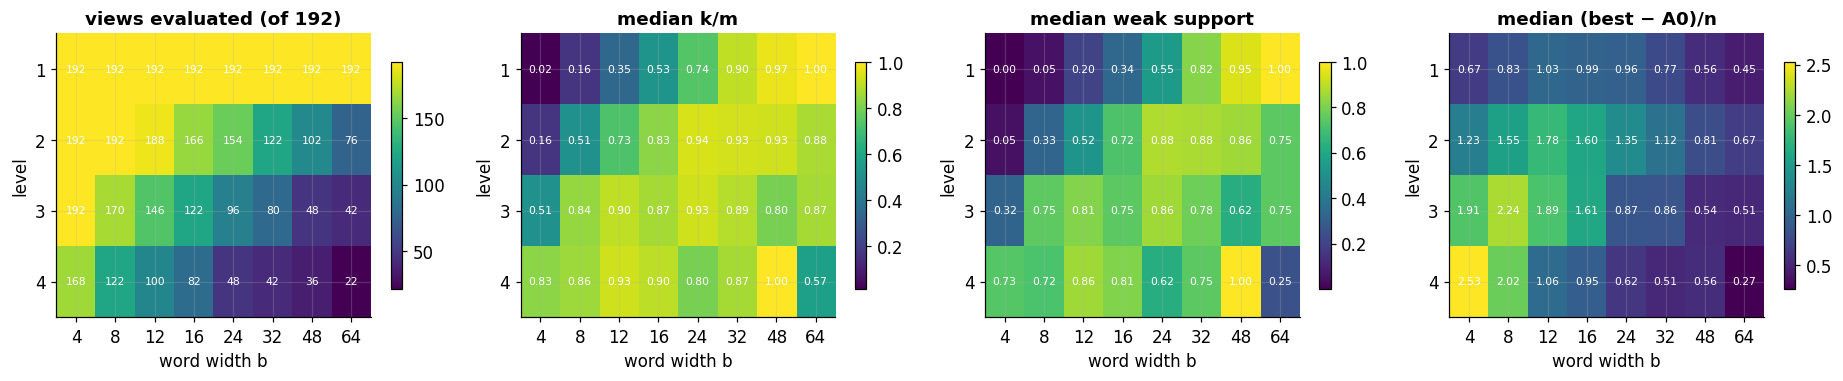

cells: 32 | views shorter than A0 in any cell: 0 | views with no admissible candidate: 0


In [7]:
W = sorted({int(g["width"]) for g in gmap}); Lv = sorted({int(g["level"]) for g in gmap})
def grid(key):
    M = np.full((len(Lv), len(W)), np.nan)
    for g in gmap:
        val = num(g[key])
        if val is not None:
            M[Lv.index(int(g["level"])), W.index(int(g["width"]))] = val
    return M
panels = [("evaluated", "views evaluated (of 192)"), ("median_k_over_m", "median k/m"),
          ("median_weak_support_fraction", "median weak support"),
          ("median_minus_a0_per_bit", "median (best − A0)/n")]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, (key, title) in zip(axes, panels):
    M = grid(key)
    im = ax.imshow(M, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(W)), W); ax.set_yticks(range(len(Lv)), Lv)
    ax.set_xlabel("word width b"); ax.set_ylabel("level"); ax.set_title(title)
    for i in range(len(Lv)):
        for j in range(len(W)):
            if not np.isnan(M[i, j]):
                ax.text(j, i, f"{M[i, j]:.2f}" if key != "evaluated" else f"{int(M[i, j])}",
                        ha="center", va="center", fontsize=7, color="w")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()
print("cells:", len(gmap), "| views shorter than A0 in any cell:", sum(int(g["shorter_than_a0"]) for g in gmap),
      "| views with no admissible candidate:", sum(int(g["no_admissible_candidate"]) for g in gmap))

## 5. Three different "gaps", kept apart

1. **Occurrence gaps** — distances between repeats of one word; the G2/G3 templates use
   the two most frequent. When the template plus at most 64 paid bit flips cannot
   reproduce the view, the proposal is rejected (no archive).
2. **Weak repetition support** — bits under words that occur once. Saturated views
   (every word distinct) end their path; their words can still be internally periodic,
   which this proxy does not see.
3. **Description gap** — the measured code-length difference to A0.

In [8]:
for arm in ("A1", "A2", "A3"):
    print(arm, summary["workload"][arm]["proposal_status"])
sat = [r for r in views if r["status"] == "EVALUATED" and r["k"] == r["m"]]
print("\nsaturated evaluated views:", len(sat), "| of which with at least one internally periodic word:",
      sum(1 for r in sat if int(r["dict_proper_repeat"]) > 0))

A1 {'G0:SERIALIZED_DECODED': 192, 'G1:DUPLICATE_ARCHIVE': 14, 'G1:SERIALIZED_DECODED': 178, 'G2:PATCH_LIMIT_REJECTION': 154, 'G2:SERIALIZED_DECODED': 38, 'G3:NO_GAP_TEMPLATE': 14, 'G3:PATCH_LIMIT_REJECTION': 168, 'G3:SERIALIZED_DECODED': 10}
A2 {'G0:DUPLICATE_ARCHIVE': 1, 'G0:SERIALIZED_DECODED': 1535, 'G1:DUPLICATE_ARCHIVE': 498, 'G1:SERIALIZED_DECODED': 1038, 'G2:DUPLICATE_ARCHIVE': 8, 'G2:NO_GAP_TEMPLATE': 336, 'G2:PATCH_LIMIT_REJECTION': 900, 'G2:SERIALIZED_DECODED': 292, 'G3:NO_GAP_TEMPLATE': 593, 'G3:PATCH_LIMIT_REJECTION': 861, 'G3:SERIALIZED_DECODED': 82}
A3 {'G0:DUPLICATE_ARCHIVE': 20, 'G0:SERIALIZED_DECODED': 4224, 'G1:DUPLICATE_ARCHIVE': 1728, 'G1:SERIALIZED_DECODED': 2516, 'G2:DUPLICATE_ARCHIVE': 48, 'G2:NO_GAP_TEMPLATE': 1112, 'G2:PATCH_LIMIT_REJECTION': 2216, 'G2:SERIALIZED_DECODED': 868, 'G3:NO_GAP_TEMPLATE': 2055, 'G3:PATCH_LIMIT_REJECTION': 2017, 'G3:SERIALIZED_DECODED': 172}

saturated evaluated views: 1112 | of which with at least one internally periodic word: 82


## 6. What it cost

Physical totals count each job once. The attributed deployment cost charges the single
A0 run in full to every composite (A0 then augmentation), so no composite is cheaper than A0.

In [9]:
rt = summary["runtime"]
print("A0 worker wall (s): sum", round(rt["physical"]["A0_worker_wall_s"]["sum"], 2),
      "max", round(rt["physical"]["A0_worker_wall_s"]["max"], 3))
for arm in ("A1", "A2", "A3"):
    d = rt["attributed_deployment"][arm]["deployment_wall_s"]
    p = rt["physical"][f"{arm}_worker_wall_s"]
    print(f"{arm}: augmentation sum {p['sum']:.2f} s, max {p['max']:.3f} s | deployment (A0 + aug) "
          f"median {d['median']:.3f} s, max {d['max']:.3f} s")

A0 worker wall (s): sum 44.32 max 0.968
A1: augmentation sum 7.06 s, max 0.093 s | deployment (A0 + aug) median 0.403 s, max 1.046 s
A2: augmentation sum 8.84 s, max 0.129 s | deployment (A0 + aug) median 0.415 s, max 1.096 s
A3: augmentation sum 14.07 s, max 0.262 s | deployment (A0 + aug) median 0.467 s, max 1.171 s


## What this result can and cannot say

* **A negative engineering-feasibility result on exposed strings.** Under this fixed
  vocabulary (paid words, paired words, runs, owner pair grammar, gap templates with at
  most 64 flips) no proposal was shorter than A0. It does not show that multilevel
  structure is absent; it shows these proposals did not pay for their dictionaries here.
* **Maps are diagnostics,** computed on exposed data; deeper cells are selected subsets.
  They do not locate a universal word length or threshold.
* **No fractal or causal reading.** A grammar hierarchy over a static string has no time
  axis and no intervention model.